# **EDA of WhatsApp Integrity Data**

In [101]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [117]:
# Always use the correct relative path from the notebook's working directory
import pandas as pd
df = pd.read_csv("data/data.csv")
print('Shape:', df.shape)
df.head(3)

Shape: (2801, 9)


,id,sender_phone,is_business,spam_report_count,about_text,is_verified_biz,body,spoofed_sender,label
0,phish-0418,9.230000e+11,1.0,157.0,Lucky Draw Verification,0.0,"You won Rs.50,000! Claim here http://reward.xyz",attacker@threat-mail.xyz,phishing
1,phish-0431,9.230000e+11,1.0,132.0,Lucky Draw Verification,0.0,"You won Rs.50,000! Claim here http://reward.xyz",attacker@threat-mail.xyz,phishing
2,phish-0445,9.230000e+11,1.0,198.0,Bank Helpdesk,0.0,Your account is locked. Verify now at http://s...,attacker@threat-mail.xyz,phishing


In [103]:
df.shape

(2801, 8)

- **Categorical**: is_business, is_verified_biz, label

- **Numerical**: spam_report_count

- **Mixed**: sender_phone,about_text, body, spoofed_sender

In [83]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2801 entries, 0 to 2800
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sender_phone       2116 non-null   float64
 1   is_business        2116 non-null   float64
 2   spam_report_count  2116 non-null   float64
 3   about_text         2116 non-null   str    
 4   is_verified_biz    2116 non-null   float64
 5   body               2116 non-null   str    
 6   spoofed_sender     2116 non-null   str    
 7   label              2116 non-null   str    
dtypes: float64(4), str(4)
memory usage: 175.2 KB


In [89]:
# calculate % of missing values in each column
df.isnull().sum()*100/len(df)


sender_phone         24.455552
is_business          24.455552
spam_report_count    24.455552
about_text           24.455552
is_verified_biz      24.455552
body                 24.455552
spoofed_sender       24.455552
label                24.455552
dtype: float64

In [90]:
df.dropna(inplace=True)

In [91]:
df.shape

(2116, 8)

In [88]:
df.duplicated().sum()

np.int64(1125)

We had 494 Duplicates.

In [87]:
# show me duplicated rows
df[df.duplicated()]

,sender_phone,is_business,spam_report_count,about_text,is_verified_biz,body,spoofed_sender,label
27,9.230000e+11,1.0,141.0,BISP Rewards Officer,0.0,Your account is locked. Verify now at http://s...,attacker@threat-mail.xyz,phishing
108,9.230000e+11,1.0,2.0,At work,1.0,Are you coming to the university tomorrow?,trusted@domain.edu.pk,safe
110,9.230000e+11,1.0,3.0,At work,1.0,"Hey, check the lab assignment details on the p...",trusted@domain.edu.pk,safe
113,9.230000e+11,1.0,3.0,Busy,1.0,"Hey, check the lab assignment details on the p...",trusted@domain.edu.pk,safe
115,9.230000e+11,0.0,3.0,Hey there! I am using WhatsApp.,0.0,Are you coming to the university tomorrow?,trusted@domain.edu.pk,safe
...,...,...,...,...,...,...,...,...
2796,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2797,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2798,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2799,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [77]:
df.drop_duplicates(inplace=True)

In [79]:
df.label.value_counts()

label
phishing    1942
safe         364
Name: count, dtype: int64

In [70]:
df.is_business.value_counts()

is_business
0    1018
1     988
Name: count, dtype: int64

ValueError: Could not interpret value `wa_is_business` for `x`. An entry with this name does not appear in `data`.

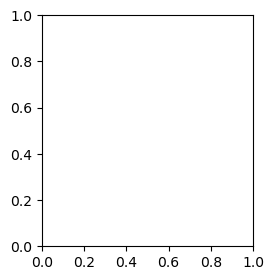

In [67]:
plt.figure(figsize=(6, 3))
plt.subplot(1, 2, 1)
sns.countplot(data=df, x='wa_is_business', hue='wa_label')

plt.title('Business vs Private Accounts')
plt.xlabel('Account Type (0: Private, 1: Business)')
plt.ylabel('Number of Accounts')

plt.subplot(1, 2, 2)
sns.countplot(data=df, x='wa_is_verified_biz', hue='wa_label')
plt.title('Verified Business Accounts')
plt.xlabel('Is Verified Business (0: No, 1: Yes)')
plt.ylabel('Number of Accounts')
plt.tight_layout()
plt.show()

- Both Business and private accounts are equally involved in cyber threats.
- All verified Accounts are safe

